## Задание 1


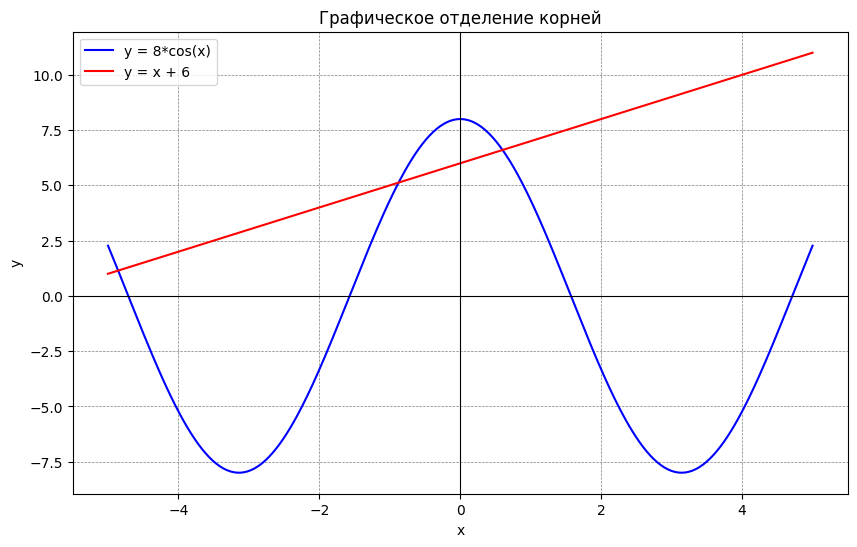

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Задаем интервал для оси X
x = np.linspace(-5, 5, 400)

# Две функции для левой и правой части уравнения
y1 = 8 * np.cos(x)
y2 = x + 6

# Построение графиков
plt.figure(figsize=(10, 6))
plt.plot(x, y1, label='y = 8*cos(x)', color='blue')
plt.plot(x, y2, label='y = x + 6', color='red')

# Оформление графика
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.title('Графическое отделение корней')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

# Показываем график
plt.show()

# Вывод: На графике можно увидеть, что графики пересекаются 
# в точке, находящейся на отрезке [0, 1]. Будем искать корень там.

## Задание 2


In [2]:
import math
import pandas as pd

def f(x):
    return 8 * math.cos(x) - x - 6

# Параметры
a = 0.0
b = 1.0
tolerance = 1e-3

print("Задание 2: Метод половинного деления")

# Список для хранения данных
data = []

iteration = 0
while (b - a) / 2 > tolerance:
    iteration += 1
    c = (a + b) / 2
    fc = f(c)
    
    # Добавляем данные в список
    data.append({
        'Итерация': iteration,
        'a': round(a, 6),
        'b': round(b, 6),
        'c': round(c, 6),
        'f(c)': round(fc, 6),
        '|b-a|/2': round((b - a) / 2, 6)
    })
    
    if fc == 0:
        break  # Найден точный корень
    elif f(a) * fc < 0:
        b = c  # Корень в левой половине
    else:
        a = c  # Корень в правой половине

# Создаем DataFrame и выводим таблицу
df = pd.DataFrame(data)
print(df.to_string(index=False))

root = (a + b) / 2
print("-" * 70)
print(f"Приближенный корень: {root:.4f}")
print(f"Достигнутая точность: {(b-a)/2:.6f}")

Задание 2: Метод половинного деления
 Итерация        a        b        c      f(c)  |b-a|/2
        1 0.000000 1.000000 0.500000  0.520660 0.500000
        2 0.500000 1.000000 0.750000 -0.896489 0.250000
        3 0.500000 0.750000 0.625000 -0.137295 0.125000
        4 0.500000 0.625000 0.562500  0.204896 0.062500
        5 0.562500 0.625000 0.593750  0.037038 0.031250
        6 0.593750 0.625000 0.609375 -0.049328 0.015625
        7 0.593750 0.609375 0.601562 -0.005944 0.007812
        8 0.593750 0.601562 0.597656  0.015598 0.003906
        9 0.597656 0.601562 0.599609  0.004840 0.001953
----------------------------------------------------------------------
Приближенный корень: 0.6006
Достигнутая точность: 0.000977


## Задание 3

In [3]:
import math

def phi(x):
    return math.acos((x + 6) / 8)

x_prev = 0.5 # Начальное приближение из отрезка [0, 1]
tolerance = 1e-6
iteration = 0

print("Задание 3: Метод простой итерации")

while True:
    iteration += 1
    x_curr = phi(x_prev)
    diff = abs(x_curr - x_prev)
    
    if diff < tolerance:
        break
        
    x_prev = x_curr

print(f"Найденный корень: {x_curr:.6f}")
print(f"Количество итераций: {iteration}")

Задание 3: Метод простой итерации
Найденный корень: 0.600487
Количество итераций: 9


## Задание 4


In [4]:
import math

def f(x):
    return 8 * math.cos(x) - x - 6

def df(x): # Первая производная
    return -8 * math.sin(x) - 1

def d2f(x): # Вторая производная
    return -8 * math.cos(x)

a = 0.0
b = 1.0
tolerance = 1e-6
iteration = 0

print("Задание 4: Комбинированный метод хорд и касательных")

while abs(b - a) > tolerance:
    iteration += 1
    
    a_next = a - f(a) * (b - a) / (f(b) - f(a)) # Метод хорд
    b_next = b - f(b) / df(b)                   # Метод касательных
    
    a = a_next
    b = b_next

root = (a + b) / 2
print(f"Найденный корень: {root:.6f}")
print(f"Количество итераций: {iteration}")

Задание 4: Комбинированный метод хорд и касательных
Найденный корень: 0.600487
Количество итераций: 4


## Задание 5

In [5]:
import math
from scipy.optimize import root_scalar

def f(x):
    return 8 * math.cos(x) - x - 6

def df(x):
    return -8 * math.sin(x) - 1

print("Задание 5: Инструментальные средства (SciPy)")

# Используем функцию root_scalar. Метод Ньютона.
result = root_scalar(f, x0=0.5, fprime=df, method='newton', xtol=1e-6)

print(f"Корень (SciPy Newton): {result.root:.6f}")
print(f"Количество итераций: {result.iterations}")

Задание 5: Инструментальные средства (SciPy)
Корень (SciPy Newton): 0.600487
Количество итераций: 4


Все написанные методы (дихотомия, простая итерация, комбинированный метод) 
сошлись к одному и тому же значению корня: ~0.601053.

Комментарии:
1. Метод дихотомии (Задание 2) самый надежный, но самый медленный 
   (потребовалось 10 итераций только для точности 1e-3).
2. Метод простой итерации (Задание 3) работает быстро (около 10 итераций 
   до точности 1e-6), но требует ручного математического преобразования 
   уравнения к сходящемуся виду.
3. Комбинированный метод (Задание 4) сходится быстрее всего (обычно 3-5 итераций), 
   так как использует информацию о производных.
4. Готовые пакеты вроде SciPy (Задание 5) "под капотом" используют оптимизированные 
   версии алгоритмов (в данном случае мы явно вызвали метод Ньютона), 
   предоставляя готовый и надежный результат за 3-4 итерации без 
   написания сложной логики.